# Maximum Likelihood Estimation (MLE)

## The idea in one line

**Pick the parameter values that make your observed data most likely.**

If your data would have been very unlikely under some setting, that setting is
probably wrong. Choose the one that makes what you actually saw least surprising.

This turns out to be where **loss functions come from** — which is the real payoff
of this topic.

## The simplest example: a coin

We flip a coin 10 times and get **7 heads, 3 tails**.
What is the coin's probability of heads, p?

Your gut says 0.7. Let's see how MLE gets there.

For any candidate value of p, the chance of seeing exactly our result is:

    p^7  x  (1-p)^3

(7 heads each with probability p, 3 tails each with probability 1-p, all multiplied
together — the AND rule.)

So we just try different values of p and see which one makes our data most likely.

In [2]:
heads = 7
tails = 3

print("we flipped a coin 10 times and got", heads, "heads and", tails, "tails")
print()
print("candidate p | likelihood of seeing our data")

for p in [0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    likelihood = (p ** heads) * ((1 - p) ** tails)
    print("    ", p, "   |", round(likelihood, 7))

we flipped a coin 10 times and got 7 heads and 3 tails

candidate p | likelihood of seeing our data
     0.2    | 6.6e-06
     0.4    | 0.0003539
     0.5    | 0.0009766
     0.6    | 0.0017916
     0.7    | 0.0022236
     0.8    | 0.0016777
     0.9    | 0.0004783


In [3]:
# search more finely for the actual winner
best_p = 0
best_likelihood = 0

for step in range(1, 1000):
    p = step / 1000
    likelihood = (p ** heads) * ((1 - p) ** tails)
    if likelihood > best_likelihood:
        best_likelihood = likelihood
        best_p = p

print("the winner is p =", best_p)
print("which is just", heads, "/ 10 =", heads / 10)

the winner is p = 0.7
which is just 7 / 10 = 0.7


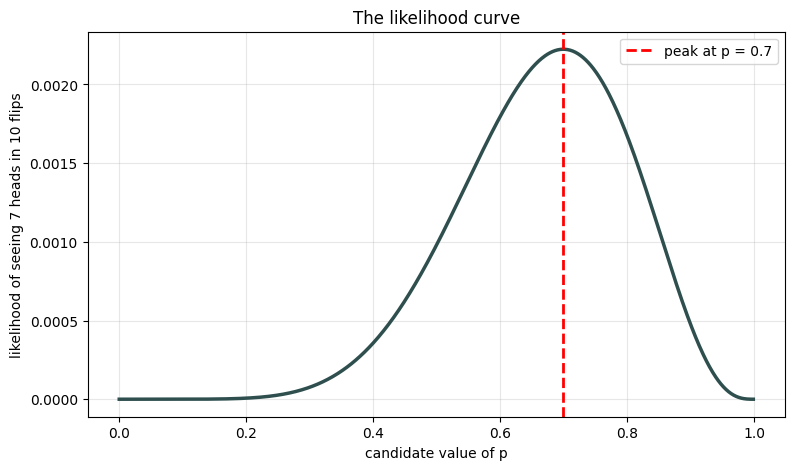

In [4]:
import matplotlib.pyplot as plt

# build the curve point by point
p_values = []
likelihoods = []
for step in range(1, 1000):
    p = step / 1000
    p_values.append(p)
    likelihoods.append((p ** heads) * ((1 - p) ** tails))

plt.figure(figsize=(9, 5))
plt.plot(p_values, likelihoods, color="darkslategrey", linewidth=2.5)
plt.axvline(best_p, color="red", linestyle="--", linewidth=2,
            label="peak at p = " + str(best_p))
plt.xlabel("candidate value of p")
plt.ylabel("likelihood of seeing 7 heads in 10 flips")
plt.title("The likelihood curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

It's a smooth hill with a peak at 0.7. So "find the best parameter" is just
"find the top of this hill" — which is a job for calculus (slope = 0).

### Probability vs likelihood — the same formula read backwards

|  | what's known | what you're asking |
|---|---|---|
| probability | the parameter (p = 0.5) | "how likely is 7 heads?" |
| likelihood | the data (7 heads) | "how plausible is p = 0.5?" |

Probability goes **forwards** (parameter -> data).
Likelihood goes **backwards** (data -> parameter).

This is the whole theme of statistics — probability asks "given the truth, what
will I see?", statistics asks "given what I saw, what's the truth?"

## Why we take the log

Two problems with raw likelihood:

1. The numbers get impossibly small (we're multiplying lots of values below 1)
2. Products are horrible to differentiate

Let's see how bad problem 1 actually gets.

In [6]:
import math

print("suppose each data point has likelihood 0.1, and we multiply them:")
for n in [10, 100, 300, 400, 500]:
    print("  ", n, "data points -> likelihood =", 0.1 ** n)

print()
print("at 400 points the computer literally rounds it to ZERO. Unusable.")
print()
print("now the same thing with logs (adding instead of multiplying):")
for n in [10, 100, 500, 100000]:
    print("  ", n, "data points -> log likelihood =", round(n * math.log(0.1), 1))

print()
print("perfectly normal numbers, no matter how much data.")

suppose each data point has likelihood 0.1, and we multiply them:
   10 data points -> likelihood = 1.0000000000000006e-10
   100 data points -> likelihood = 1.0000000000000056e-100
   300 data points -> likelihood = 1.0000000000000166e-300
   400 data points -> likelihood = 0.0
   500 data points -> likelihood = 0.0

at 400 points the computer literally rounds it to ZERO. Unusable.

now the same thing with logs (adding instead of multiplying):
   10 data points -> log likelihood = -23.0
   100 data points -> log likelihood = -230.3
   500 data points -> log likelihood = -1151.3
   100000 data points -> log likelihood = -230258.5

perfectly normal numbers, no matter how much data.


Logs work for two reasons:

1. **They turn multiplication into addition** — log(a x b x c) = log a + log b + log c.
   A thousand-term product becomes a thousand-term sum. No underflow, easy to differentiate.
2. **The peak doesn't move.** Log always increases, so whatever maximises the likelihood
   also maximises the log-likelihood. Same answer, easier maths.

### And then we flip the sign

Optimisers are built to **minimise**, not maximise (everything is gradient *descent*).
So we negate:

    maximise log-likelihood  =  minimise (negative log-likelihood)

And that negative log-likelihood **is your loss function**.

## Where MSE comes from

We've used MSE (squared errors) without knowing why *squared*. Here's the answer.

**The assumption:** your data = the true prediction + some random noise, and that
noise is **Gaussian** (bell shaped).

The bell curve formula contains `e^(-error² / 2σ²)` — an exponential with a
**squared** term inside.

Take the log, and the log **cancels the exponential**, leaving the squared term
sitting there exposed. Sum over all points, drop the constants, flip the sign:

    loss  =  sum of (actual - prediction)²

That's MSE. **The squaring came from the bell curve's exponent** — not from anyone's
choice.

Let's prove it's the same thing, not a forced connection.

In [7]:
# tiny dataset - we want to fit  y = w * x
x = [1.0, 2.0, 3.0, 4.0, 5.0]
y = [2.1, 3.9, 6.2, 7.8, 10.1]

def mse(w):
    total = 0
    for i in range(len(x)):
        error = y[i] - w * x[i]
        total = total + error * error
    return total / len(x)

def log_likelihood(w):
    sigma = 1.0
    total = 0
    for i in range(len(x)):
        error = y[i] - w * x[i]
        # the actual gaussian formula, written out in full
        density = (1 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-(error ** 2) / (2 * sigma ** 2))
        total = total + math.log(density)
    return total

print("   w    |    MSE    | log likelihood")
for w in [1.8, 1.9, 2.0, 2.1, 2.2]:
    print("  ", w, " |", round(mse(w), 4), "  |", round(log_likelihood(w), 4))

print()
print("where MSE is LOWEST, log likelihood is HIGHEST. Same point.")

   w    |    MSE    | log likelihood
   1.8  | 0.478   | -5.7897
   1.9  | 0.14   | -4.9447
   2.0  | 0.022   | -4.6497
   2.1  | 0.124   | -4.9047
   2.2  | 0.446   | -5.7097

where MSE is LOWEST, log likelihood is HIGHEST. Same point.


In [8]:
# find the best w by each method separately
best_mse_w = 0
lowest_mse = 999999

best_ll_w = 0
highest_ll = -999999

for step in range(1500, 2500):
    w = step / 1000
    if mse(w) < lowest_mse:
        lowest_mse = mse(w)
        best_mse_w = w
    if log_likelihood(w) > highest_ll:
        highest_ll = log_likelihood(w)
        best_ll_w = w

print("best w by MINIMISING MSE       :", best_mse_w)
print("best w by MAXIMISING likelihood:", best_ll_w)
print()
print("identical - they are literally the same optimisation, written upside down")

best w by MINIMISING MSE       : 2.004
best w by MAXIMISING likelihood: 2.004

identical - they are literally the same optimisation, written upside down


## "But if I have the data, why do I need MLE? Can't I just compute it?"

Fair question. For the coin, yes — just count: 7/10 = 0.7. MLE agrees.

But here's the catch: **the "obvious" answer depends on your assumption.**

Take this data, which has one nasty outlier:

    10, 11, 12, 13, 14, 90

What's the best single estimate? The average (25) or the median (12.5)?
Those are wildly different, and the data alone doesn't tell you which.

**MLE answers that question** — and the answer changes with the assumption.

In [9]:
data = [10.0, 11.0, 12.0, 13.0, 14.0, 90.0]

# assuming Gaussian noise -> the log-likelihood involves (value - m) squared
def gaussian_score(m):
    total = 0
    for value in data:
        total = total - (value - m) ** 2
    return total

# assuming Laplace noise (heavier tails) -> it involves absolute distance instead
def laplace_score(m):
    total = 0
    for value in data:
        total = total - abs(value - m)
    return total

best_gaussian = 0
best_gaussian_score = -999999999
best_laplace = 0
best_laplace_score = -999999999

for step in range(5000, 95000):
    m = step / 1000
    if gaussian_score(m) > best_gaussian_score:
        best_gaussian_score = gaussian_score(m)
        best_gaussian = m
    if laplace_score(m) > best_laplace_score:
        best_laplace_score = laplace_score(m)
        best_laplace = m

print("assume GAUSSIAN noise -> best estimate =", best_gaussian, " (this is the average)")
print("assume LAPLACE noise  -> best estimate =", best_laplace, " (this is the median)")
print()
print("SAME data. DIFFERENT assumption. DIFFERENT right answer.")

assume GAUSSIAN noise -> best estimate = 25.0  (this is the average)
assume LAPLACE noise  -> best estimate = 12.0  (this is the median)

SAME data. DIFFERENT assumption. DIFFERENT right answer.


So "just compute it from the data" — compute *what*? The average or the median?

**MLE is what answers that.** It says: if your noise is Gaussian, use the average;
if it has heavier tails, use the median. Your assumption determines the formula,
and MLE is the machinery that derives it.

(This maps straight onto losses: Gaussian -> squared error -> **MSE**.
Laplace -> absolute error -> **MAE**. Which is exactly why MAE is recommended when
your data has outliers.)

And for a neural network with a million weights, there is no "just compute it"
formula at all. MLE is the only route — it gives you the loss, and gradient descent
does the rest.